# 06 Model Comparison


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

PROJECT_ROOT = Path("..").resolve()
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = REPORT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## Comparison Table


In [4]:
model_results = pd.DataFrame(
    [
        {
            "model": "Logistic Regression",
            "approach": "Supervised classification",
            "accuracy": 0.9537,
            "roc_auc": 0.9712,
            "pr_auc": 0.2189,
            "fraud_precision": 0.0286,
            "fraud_recall": 0.9091,
            "fraud_f1": 0.0554,
            "training_time_seconds": 2.89,
        },
        {
            "model": "Random Forest",
            "approach": "Supervised classification",
            "accuracy": 0.9410,
            "roc_auc": 0.9651,
            "pr_auc": 0.2826,
            "fraud_precision": 0.0222,
            "fraud_recall": 0.8930,
            "fraud_f1": 0.0433,
            "training_time_seconds": 25.29,
        },
        {
            "model": "Decision Tree",
            "approach": "Supervised classification",
            "accuracy": 0.9682,
            "roc_auc": 0.8882,
            "pr_auc": 0.1947,
            "fraud_precision": 0.0383,
            "fraud_recall": 0.8396,
            "fraud_f1": 0.0732,
            "training_time_seconds": 8.42,
        },

        {
            "model": "KNN",
            "approach": "Supervised classification",
            "accuracy": 0.9986,
            "roc_auc": 0.6884,
            "pr_auc": 0.2195,
            "fraud_precision": 0.6667,
            "fraud_recall": 0.0541,
            "fraud_f1": 0.1000,
            "training_time_seconds": 0.13,
        },
        {
            "model": "K-Means Clustering",
            "approach": "Unsupervised clustering",
            "accuracy": 0.4816,
            "roc_auc": 0.5967,
            "pr_auc": 0.0027,
            "fraud_precision": 0.0016,
            "fraud_recall": 0.5668,
            "fraud_f1": 0.0033,
            "training_time_seconds": 1.27,
        },
    ]
)

model_results

,model,approach,accuracy,roc_auc,pr_auc,fraud_precision,fraud_recall,fraud_f1,training_time_seconds
0,Logistic Regression,Supervised classification,0.9537,0.9712,0.2189,0.0286,0.9091,0.0554,2.89
1,Random Forest,Supervised classification,0.9410,0.9651,0.2826,0.0222,0.8930,0.0433,25.29
2,Decision Tree,Supervised classification,0.9682,0.8882,0.1947,0.0383,0.8396,0.0732,8.42
3,KNN,Supervised classification,0.9986,0.6884,0.2195,0.6667,0.0541,0.1000,0.13
4,K-Means Clustering,Unsupervised clustering,0.4816,0.5967,0.0027,0.0016,0.5668,0.0033,1.27


In [5]:
model_results_path = REPORT_DIR / "model_results.csv"
model_results.to_csv(model_results_path, index=False)
print(f"Model results saved to: {model_results_path}")


Model results saved to: C:\Big-Data-Project\reports\model_results.csv


## Overall Metrics Comparison


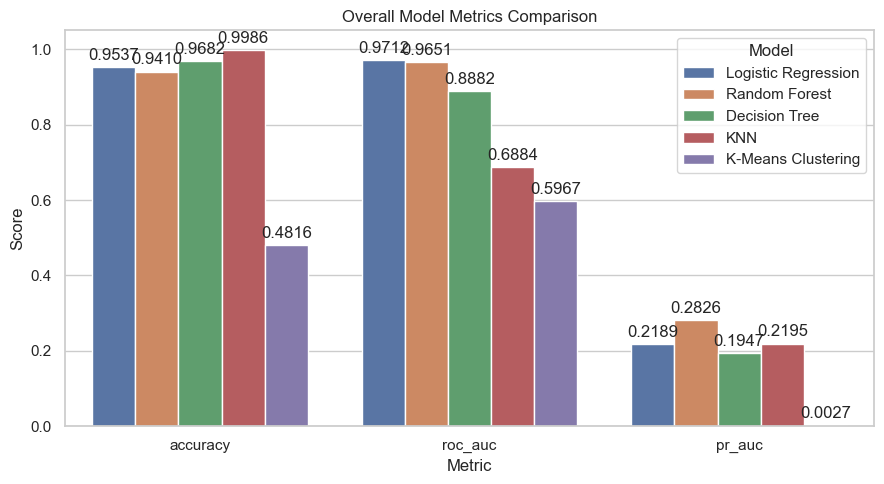

In [14]:
overall_metrics = model_results.melt(
    id_vars="model",
    value_vars=["accuracy", "roc_auc", "pr_auc"],
    var_name="metric",
    value_name="score",
).dropna(subset=["score"])

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=overall_metrics, x="metric", y="score", hue="model", ax=ax)
ax.set_title("Overall Model Metrics Comparison")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend(title="Model", loc="upper right")
fig.tight_layout()

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

fig.savefig(FIGURE_DIR / "comparison_overall_model_metrics.png", dpi=160, bbox_inches="tight")
plt.show()

## Fraud-Class Metrics Comparison


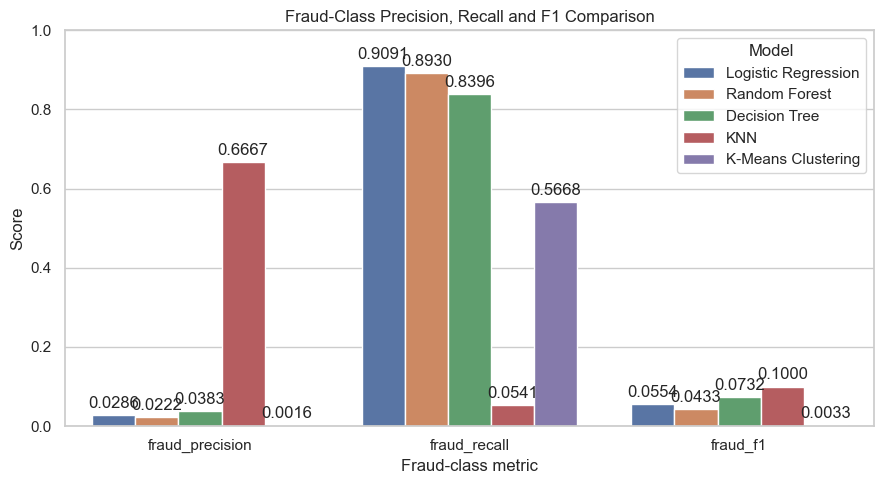

In [12]:
fraud_metrics = model_results.melt(
    id_vars="model",
    value_vars=["fraud_precision", "fraud_recall", "fraud_f1"],
    var_name="metric",
    value_name="score",
).dropna(subset=["score"])

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=fraud_metrics, x="metric", y="score", hue="model", ax=ax)
ax.set_title("Fraud-Class Precision, Recall and F1 Comparison")
ax.set_xlabel("Fraud-class metric")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
ax.legend(title="Model", loc="upper right")
fig.tight_layout()

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)
    
fig.savefig(FIGURE_DIR / "comparison_fraud_class_metrics.png", dpi=160, bbox_inches="tight")
plt.show()

## Training Time Comparison


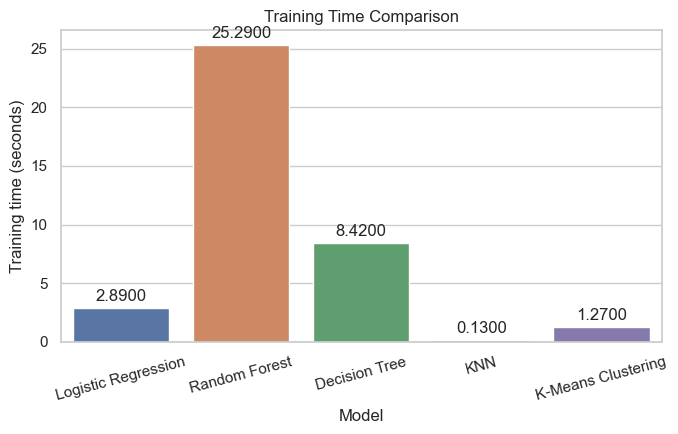

In [11]:
training_time = model_results.dropna(subset=["training_time_seconds"]) 

fig, ax = plt.subplots(figsize=(7, 4.5)) 
sns.barplot(data=training_time, x="model", y="training_time_seconds", hue="model", legend=False, ax=ax) 

ax.set_title("Training Time Comparison") 
ax.set_xlabel("Model") 
ax.set_ylabel("Training time (seconds)") 
ax.tick_params(axis="x", rotation=15) 
fig.tight_layout() 

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

fig.savefig(FIGURE_DIR / "comparison_training_time.png", dpi=160, bbox_inches="tight") 

plt.show()

## Supervised vs Unsupervised Interpretation


In [9]:
model_results.sort_values(["pr_auc", "fraud_f1"], ascending=False, na_position="last")

,model,approach,accuracy,roc_auc,pr_auc,fraud_precision,fraud_recall,fraud_f1,training_time_seconds
1,Random Forest,Supervised classification,0.9410,0.9651,0.2826,0.0222,0.8930,0.0433,25.29
3,KNN,Supervised classification,0.9986,0.6884,0.2195,0.6667,0.0541,0.1000,0.13
0,Logistic Regression,Supervised classification,0.9537,0.9712,0.2189,0.0286,0.9091,0.0554,2.89
2,Decision Tree,Supervised classification,0.9682,0.8882,0.1947,0.0383,0.8396,0.0732,8.42
4,K-Means Clustering,Unsupervised clustering,0.4816,0.5967,0.0027,0.0016,0.5668,0.0033,1.27
